In [1]:
import pandas as pd
import scanpy as sc
import numpy as np

In [2]:
sc.__version__

C:\Users\Leo\AppData\Local\Temp\ipykernel_35000\4147423214.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc.__version__


'1.11.5'

In [3]:
import scipy.sparse as sp
def filter_genes_per_donor(adata, min_cells=5, rpkm_threshold=1):
    """
    Keep genes with RPKM > rpkm_threshold in at least min_cells
    within every donor.

    RPKM + 1 > 2  <=>  RPKM > 1
    """

    # RPKM > 1
    expr_mask = adata.X >= rpkm_threshold

    # Make sure we can index the result by cells/genes
    if sp.issparse(expr_mask):
        expr_mask = expr_mask.toarray()

    donor_pass = []

    for donor in adata.obs["Donor"].unique():
        donor_mask = adata.obs["Donor"].values == donor

        # Number of cells with RPKM > 1 for each gene
        counts_per_gene = expr_mask[donor_mask].sum(axis=0)

        # At least 5 cells in this donor
        donor_pass.append(counts_per_gene >= min_cells)

    # Gene must pass in EVERY donor 
    final_gene_mask = np.all(donor_pass, axis=0)

    print(
        f"Keeping {final_gene_mask.sum()} / {adata.n_vars} genes "
        f"({100 * final_gene_mask.mean():.1f}%)"
    )

    return adata[:, final_gene_mask].copy()

# Dataset1

In [4]:
sel_genes=pd.read_excel("sel_genes.xlsx")


In [5]:
# Load data for dataset1

expr=pd.read_csv('GSE153855_Expression_RPKM_HQ_allsamples.txt', sep='\t', index_col=0, header=None)
ann=pd.read_csv('GSE153855_Cell_annotation.txt', sep='\t', index_col=0)
ann=ann.reset_index()
# anndata object from expr
adata = sc.AnnData(expr.T)
ann.index=[str(i+1) for i in ann.index.values]
# add annotations
adata.obs=adata.obs.merge(ann, left_index=True, right_index=True)

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
adata.shape

(3383, 30558)

In [7]:
# Filter genes, follow article directions
adata_filter = filter_genes_per_donor(adata)

Keeping 13205 / 30558 genes (43.2%)


In [8]:
adata_filter.shape

(3383, 13205)

In [9]:
[i for i in sel_genes.Gene_name if i not in adata_filter.var_names]

['RPS17', 'CUTA', 'TAPBP', 'MBOAT7', 'G6PC2', 'RPH3AL', 'CISD3']

In [13]:
adata[:,'RPS17'].X.sum()

array(0.)

In [14]:
adata[:,'CUTA'].X.sum()

array(0.)

In [15]:
adata[:,'TAPBP'].X.sum()

array(0.)

In [16]:
adata[:,'MBOAT7'].X.sum()

array(0.)

In [17]:
adata[:,'G6PC2'].X.sum()

array(0.)

In [18]:
adata[:,'RPH3AL'].X.sum()

array(0.)

In [19]:
adata[:,'CISD3'].X.sum()

array(0.)

In [20]:
# --------------------------------------------------
# 3. Log2(RPKM + 1)
# --------------------------------------------------

adata_filter.X = np.log2(adata_filter.X + 1)

In [21]:
# Convert observation (cell) metadata column names to strings
adata_filter.obs.columns = adata_filter.obs.columns.astype(str)


In [22]:
adata_filter.var=adata_filter.var.reset_index()
adata_filter.var.columns=['gene_name']
adata_filter.var.index=adata_filter.var.gene_name
# Convert variable (gene) metadata column names to strings
adata_filter.var.columns = adata_filter.var.columns.astype(str)

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [23]:
# Save full dataset
adata_filter.write_loom('Dataset1_full.loom') 

In [24]:
# Save betas only
adata_filter[adata_filter.obs['CellType'] == 'Beta'].write_loom('Dataset1_betas.loom') 

## Find beta cells

In [25]:
# 2. Identify Highly Variable Genes (HVGs)
sc.pp.highly_variable_genes(adata_filter)
#adata = adata[:, adata.var.highly_variable]

In [26]:
# 4. Run PCA
sc.tl.pca(adata_filter, svd_solver='arpack', n_comps=50)

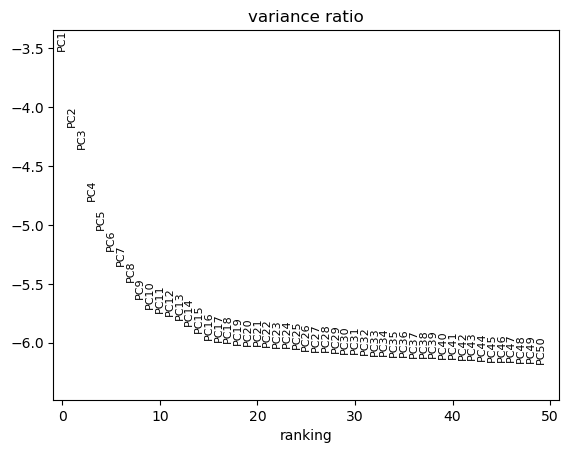

In [27]:
sc.pl.pca_variance_ratio(adata_filter, n_pcs=50, log=True)

In [28]:
# 5. Compute the neighborhood graph
# This is a prerequisite for both UMAP and Leiden

#sc.pp.neighbors(adata_filter, n_neighbors=10, n_pcs=15,)

sc.pp.neighbors(
    adata_filter, 
    n_pcs=15, 
    use_rep='X_pca', 
    method='gauss',      # Alternative to the default 'umap'
    metric='euclidean'
)

In [29]:
# 6. Run UMAP
sc.tl.umap(adata_filter)

In [30]:
adata_filter.obs.columns

Index(['Donor', 'Disease', 'CellType'], dtype='object')

C:\Users\Leo\AppData\Local\Temp\ipykernel_35000\2540696129.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_filter, resolution=0.5)


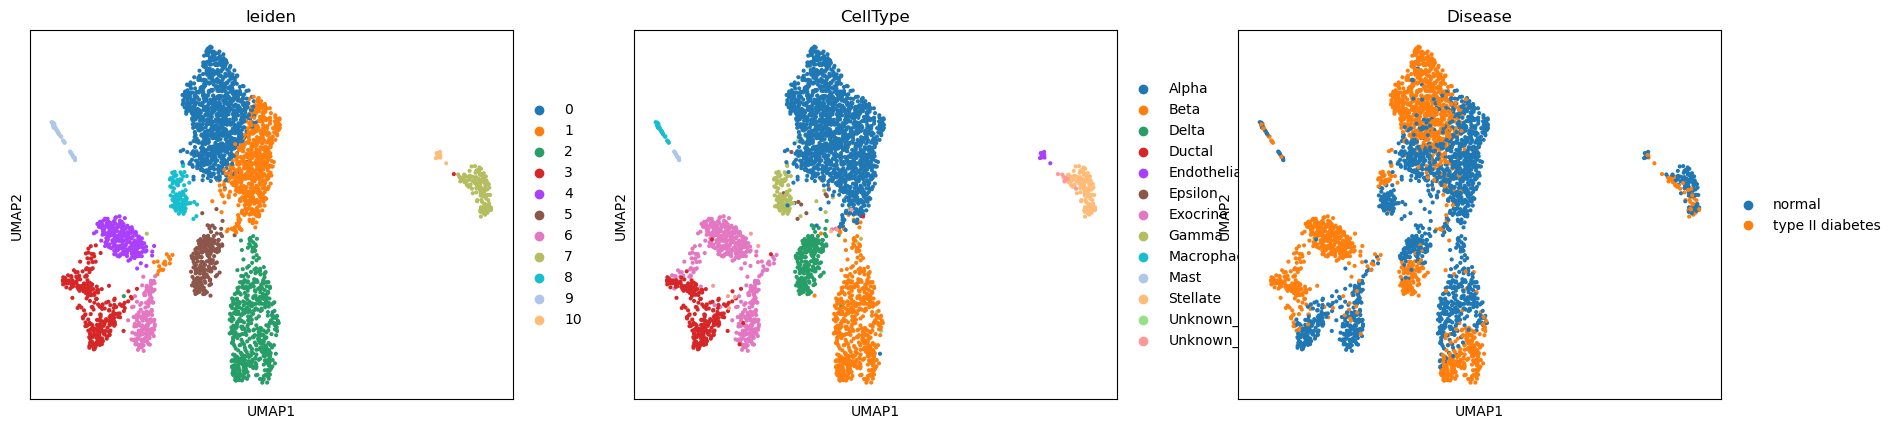

In [31]:
# 7. Cluster the cells
sc.tl.leiden(adata_filter, resolution=0.5)

# 8. Visualize
sc.pl.umap(adata_filter, color=['leiden','CellType','Disease'])

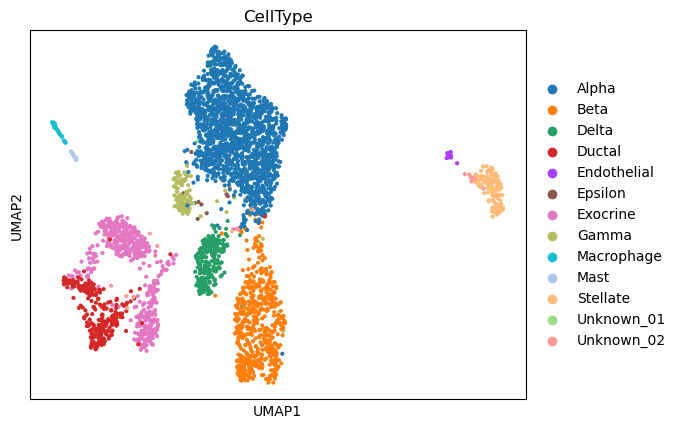

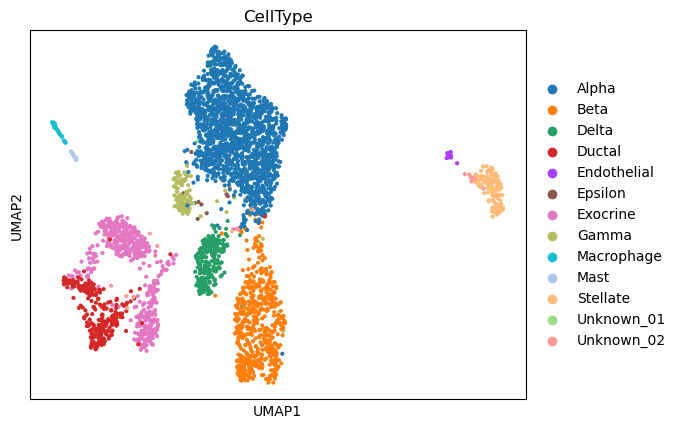

In [32]:
sc.pl.umap(adata_filter, color=['CellType'], save='Dataset_1.svg')
sc.pl.umap(adata_filter, color=['CellType'], save='Dataset_1.png')

C:\Users\Leo\anaconda3\Lib\site-packages\scanpy\tools\_dendrogram.py:138: UserWarning: You’re trying to run this on 30558 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


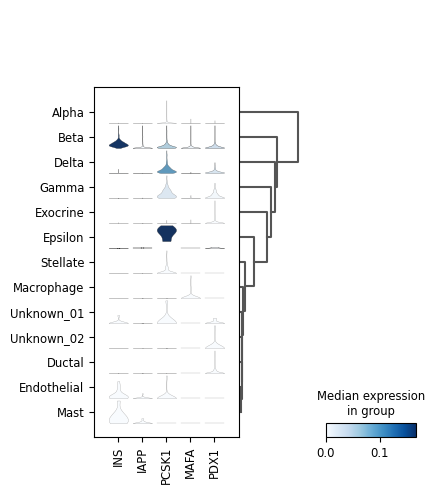

In [33]:
sc.pl.stacked_violin(adata, ['INS','IAPP','PCSK1','MAFA','PDX1'], groupby='CellType', dendrogram=True,  standard_scale='var', swap_axes=False, save='Beta_markers_Dataset_1.svg')

In [34]:
# 9. Rank genes per cluster (using Wilcoxon rank-sum test by default)
sc.tl.rank_genes_groups(adata_filter, 'leiden', method='wilcoxon')

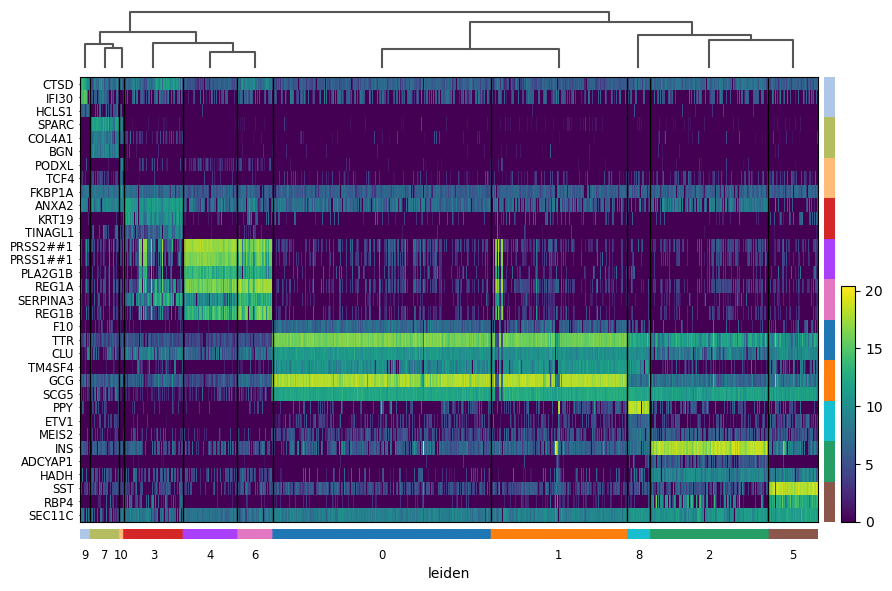

In [35]:
sc.pl.rank_genes_groups_heatmap(adata_filter, n_genes=3, swap_axes=True, groupby='leiden')

# Dataset2

In [36]:
expr=pd.read_csv('GSE214517_rpkms.txt', sep='\t', index_col=0)

In [37]:
idx_=['mix' not in i for i in expr.index.values]
expr=expr.loc[idx_].copy()

In [38]:
expr.index=[i.split('|')[0] for i in expr.index.values]

In [39]:
expr=expr.T

In [40]:
# anndata object from expr
adata = sc.AnnData(expr)

C:\Users\Leo\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Cell type-specific gene-gene correlation matrices for each cell type with more than 30 cells/donor were constructed separately for T2D and non-T2D donors using Pearson correlation between transcriptional levels in log2(RPKM + 1) of each gene pair. 

We filtered non-expressed genes (RPKM + 1 < 2) and genes detected (RPKM + 1 > 2) in less than 5 cells/donor. 

The correlations were calculated using a linear mixed-effects model including random effects to correct for donor-specific expression differences. 

To build cell type-specific differential networks between disease and healthy states, we calculated the difference in pairwise Pearson correlations for each gene pair between T2D and non-T2D donors. 

To remove false positive weights in the differential network, we used a bootstrapping approach, generating random differential networks by selecting 512 pairs of random groups of donors. We filtered all correlations with a relative frequency lower than 0.975, keeping only links that were significantly stronger than random. 

In [41]:
adata.obs['Donor']=[i.split('_')[0] for i in adata.obs.index.values]
adata.obs['Disease']=['T2D' if 'T2D' in i else 'normal' for i in adata.obs.Donor]

In [42]:
X = adata.X

# Handle sparse matrices efficiently
if hasattr(X, "toarray"):
    X = X.toarray()

# Per-cell QC metrics
adata.obs["n_genes_expressed"] = (X > 0).sum(axis=1)
adata.obs["mean_expression"] = X.mean(axis=1)

# Optional: total RPKM per cell
adata.obs["total_rpkm"] = X.sum(axis=1)

<Axes: xlabel='mean_expression', ylabel='n_genes_expressed'>

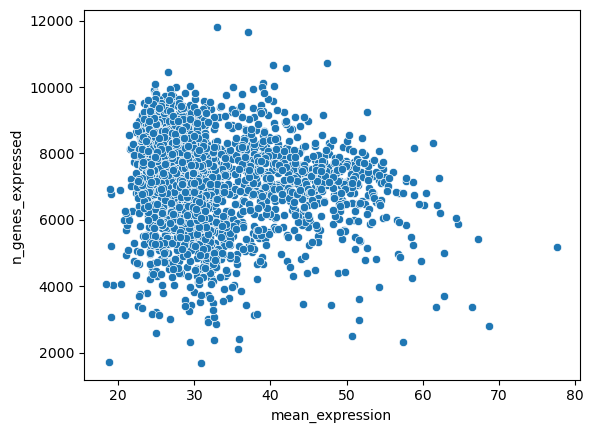

In [43]:
import seaborn as sns
sns.scatterplot(adata.obs, x='mean_expression', y='n_genes_expressed')

In [44]:
# Filter genes, follow article directions
adata_filter = filter_genes_per_donor(adata)

Keeping 14016 / 22194 genes (63.2%)


C:\Users\Leo\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [45]:
[i for i in sel_genes.Gene_name if i not in adata_filter.var_names]

[]

In [46]:
adata_filter.var_names_make_unique()

In [47]:
adata_filter.var['gene_name']=adata_filter.var.index.values

In [48]:
# --------------------------------------------------
# 3. Log2(RPKM + 1)
# --------------------------------------------------

adata_filter.X = np.log2(adata_filter.X + 1)

## Find beta cells

In [49]:
# 2. Identify Highly Variable Genes (HVGs)
sc.pp.highly_variable_genes(adata_filter)
#adata = adata[:, adata.var.highly_variable]

In [50]:
# 4. Run PCA
sc.tl.pca(adata_filter, svd_solver='arpack', n_comps=50)

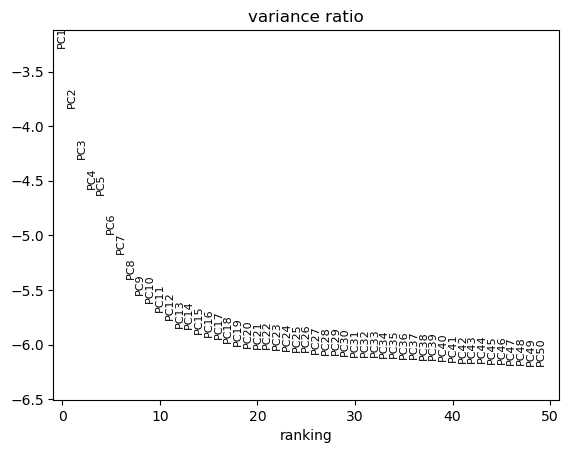

In [51]:
sc.pl.pca_variance_ratio(adata_filter, n_pcs=50, log=True)

In [52]:
# 5. Compute the neighborhood graph
# This is a prerequisite for both UMAP and Leiden

#sc.pp.neighbors(adata_filter, n_neighbors=10, n_pcs=15,)

sc.pp.neighbors(
    adata_filter, 
    n_pcs=15, 
    use_rep='X_pca', 
    method='gauss',      # Alternative to the default 'umap'
    metric='euclidean'
)

In [53]:
# 6. Run UMAP
sc.tl.umap(adata_filter)

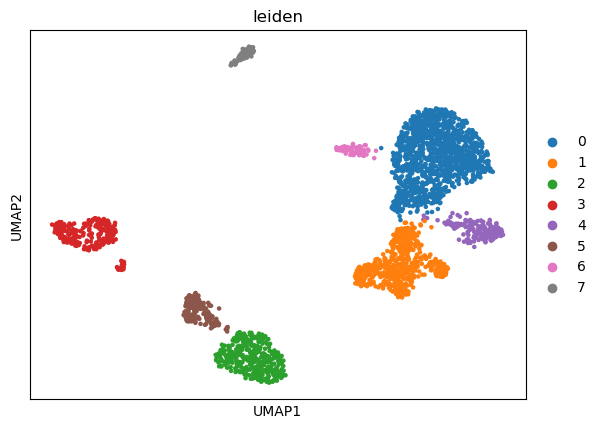

In [54]:
# 7. Cluster the cells
sc.tl.leiden(adata_filter, resolution=0.2)

# 8. Visualize
sc.pl.umap(adata_filter, color=['leiden'])

In [55]:
# 9. Rank genes per cluster (using Wilcoxon rank-sum test by default)
sc.tl.rank_genes_groups(adata_filter, 'leiden', method='wilcoxon')

# 10. Visualize the top 5 markers per cluster
#sc.pl.rank_genes_groups(adata_filter, n_genes=25, sharey=False)

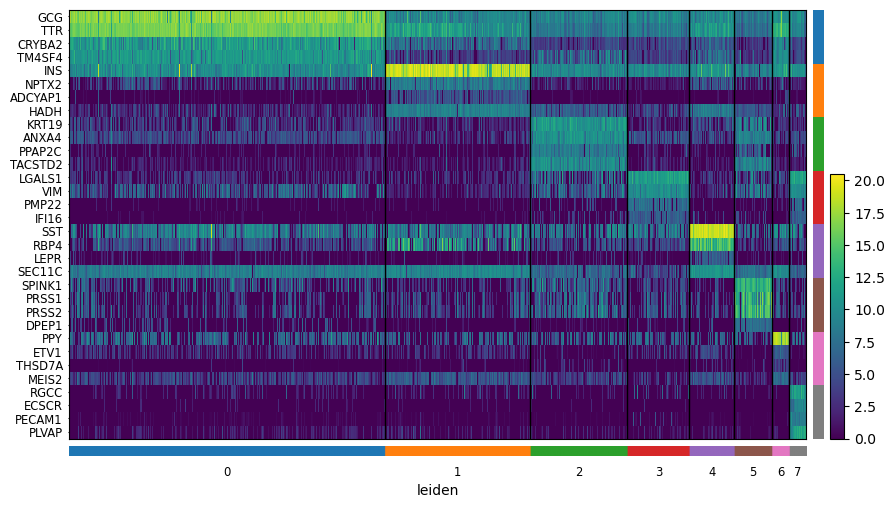

In [56]:
sc.pl.rank_genes_groups_heatmap(adata_filter, n_genes=4, swap_axes=True, groupby='leiden',dendrogram=False)

| Leiden Cluster | Primary Marker Genes | Assigned Cell Identity |
|---|---|---|
| 0, 1 | GCG, TTR | Alpha (α) cells |
| 2 | INS | Beta (β) cells |
| 3 | KRT19, ANXA4 | Ductal cells |
| 4 | SST | Delta (δ) cells |
| 5 | COL1A2, CALD1 | Stellate cells / Fibroblasts |
| 6 | SPINK1, GSTA2 | Acinar cells |
| 7 | ECSCR, ELTD1 | Endothelial cells |
| 8 | TYROBP, LCP1 | Immune cells (Myeloid/Macrophage) |

In [57]:
cell_type_map = {
    "0": "Alpha",
    "1": "Beta",
    "2": "Ductal",
    "4": "Delta",
    "3": "Stellate/Fibroblast",
    "5": "Acinar",
    "7": "Endothelial",
    "6": "Gamma"
}

adata_filter.obs["CellType"] = adata_filter.obs["leiden"].map(cell_type_map)

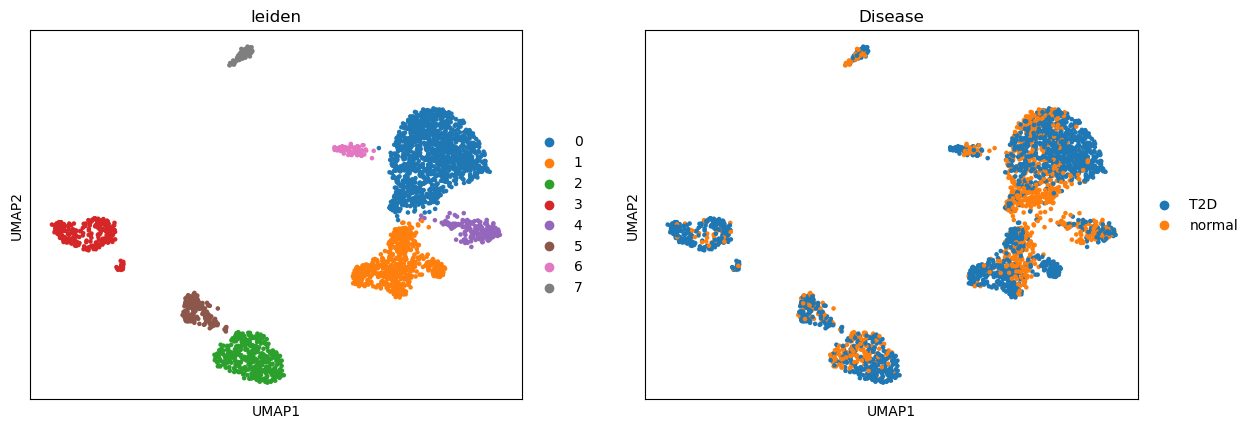

In [58]:
sc.pl.umap(adata_filter, color=['leiden','Disease'])

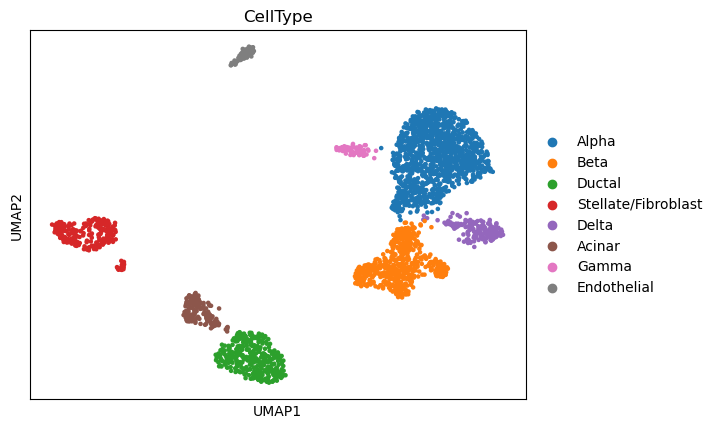

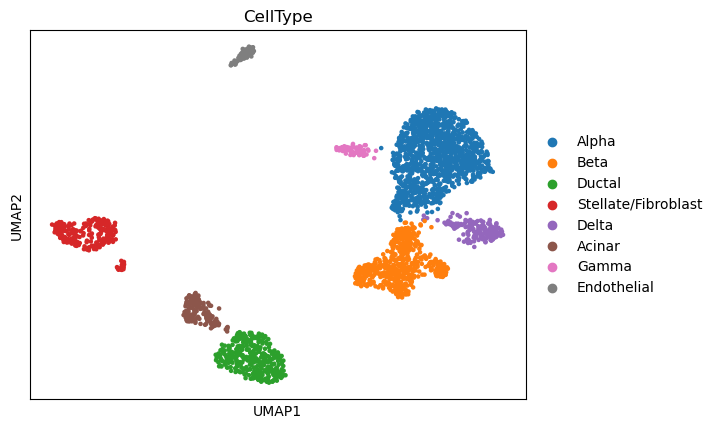

In [59]:
sc.pl.umap(adata_filter, color=['CellType'], save='Dataset_2.svg')
sc.pl.umap(adata_filter, color=['CellType'], save='Dataset_2.png')

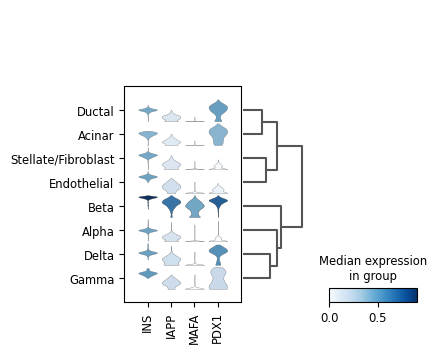

In [60]:
sc.pl.stacked_violin(adata_filter, ['INS','IAPP','MAFA','PDX1'], groupby='CellType', dendrogram=True,  standard_scale='var', swap_axes=False, save='Beta_markers_Dataset_2.svg')



In [61]:
# Save full dataset
adata_filter.write_loom('Dataset2_full.loom') 

The loom file will lack these fields:
{'X_pca', 'PCs', 'X_umap'}
Use write_obsm_varm=True to export multi-dimensional annotations


In [62]:
# Save betas only
adata_filter[adata_filter.obs['CellType'] == 'Beta'].write_loom('Dataset2_betas.loom') 

The loom file will lack these fields:
{'X_pca', 'PCs', 'X_umap'}
Use write_obsm_varm=True to export multi-dimensional annotations
